# 06 · Análisis intra-municipal: San Miguel de Allende (11003)

## Objetivo

Este notebook construye una **capa de análisis sub-municipal** para San Miguel de Allende (SMA), con el fin de
identificar localidades, colonias y zonas de atención médica con mayor necesidad de **programas de activación
física**, como insumo para una propuesta concreta a **COMUDE San Miguel de Allende** (Instituto Municipal del
Deporte).

A diferencia de los notebooks anteriores (que trabajan a nivel municipio), aquí el municipio de análisis es fijo
(San Miguel de Allende, clave INEGI **11003**) y la unidad de análisis pasa a ser la **localidad / colonia / unidad
de salud**.

## Fuentes de datos nuevas

| Fuente | Nivel | Cobertura SMA | Variables clave |
|---|---|---|---|
| `DA_EC_SIS_2023.csv` (DGIS/SIS) | Unidad de salud (CLUES) | 22 unidades | Adultos en control: diabetes, hipertensión, obesidad, dislipidemia, síndrome metabólico |
| `iml_2020.csv` (CONAPO, Índice de marginación por localidad 2020) | Localidad | 331 localidades | Índice y grado de marginación, población, indicadores socioeconómicos |
| `imuc_2020.csv` (CONAPO, Índice de marginación urbana 2020) | Colonia | 121 colonias (cabecera) | Índice y grado de marginación urbana, población, carencias de vivienda |

## Estrategia general

1. Filtrar las tres bases para SMA (`CLAVE_ENTIDAD/ENT/CVE_ENT = 11`, `CLAVE_MUNICIPIO/MUN/CVE_MUN = 3 o 11003`).
2. Hacer EDA y manejo de nulos justificado en cada base (igual que en notebooks anteriores).
3. Construir un **crosswalk** entre las 22 unidades de salud (CLUES) y las localidades de `iml_2020`, usando el
   nombre de la unidad (ej. `ALCOCER-UMAPS` → localidad *Alcocer*).
4. Combinar carga de enfermedad (registros en control, normalizados por población) con marginación a nivel
   localidad → **índice de prioridad rural**.
5. Para la cabecera municipal (atendida por una sola unidad, `SAN MIGUEL DE ALLENDE-CAISES`), usar `imuc_2020`
   para identificar las **colonias urbanas con mayor marginación**, ya que no es posible desagregar la carga de
   enfermedad por colonia con los datos disponibles.
6. Generar visualizaciones y un dataset final `sma_localidades_panel.csv` + `sma_colonias_panel.csv` para usarse
   en el dashboard y en la propuesta a COMUDE.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

RAW = '../data/raw/'
PROC = '../data/processed/'


## 1. Registros en control de enfermedades crónicas (DA_EC_SIS_2023)

Esta base es un **cubo dinámico del SIS (DGIS)** con reportes mensuales por unidad de salud (CLUES) del número
de personas adultas registradas **"en control"** por distintos padecimientos crónicos, desagregado por 12 columnas
(6 grupos de edad × 2 sexos según convención DGIS).

Prefijos relevantes:

- **ADM** — Adultos en control por **Diabetes Mellitus**
- **AHA** — Adultos en control por **Hipertensión Arterial**
- **AOB** — Adultos en control por **Obesidad**
- **ADL** — Adultos en control por **Dislipidemia**
- **AEC** — Adultos en control por **síndrome metabólico / exceso de peso** (agrupador)

El resto de columnas (`HBA*`, `PDM*`, `FRS*`, `PMA*`, `RUN01`) corresponden a indicadores adicionales (control de
hemoglobina glicosilada, factores de riesgo, etc.) cuyo diccionario exacto no pudimos confirmar con el catálogo
oficial — se documentan pero **no se usan** en el índice de prioridad para evitar interpretaciones erróneas.


In [2]:
df_sis = pd.read_csv(RAW + 'DA_EC_SIS_2023.csv', encoding='latin-1', low_memory=False)
df_sis.columns = [c.replace('ï»¿', '') for c in df_sis.columns]

sma_sis = df_sis[(df_sis.CLAVE_ENTIDAD == 11) & (df_sis.CLAVE_MUNICIPIO == 3)].copy()
print('Filas SMA:', sma_sis.shape)
print('Unidades de salud (CLUES):', sma_sis.CLUES.nunique())
sorted(sma_sis.NOMBRE_CLUES.unique())


Filas SMA: (264, 86)
Unidades de salud (CLUES): 22


['AGUSTIN GONZALEZ-UMAPS',
 'ALCOCER-UMAPS',
 'CARAVANA TIPO 0 LA HUERTA',
 'CARAVANA TIPO II CIENEGA DE JUANA RUIZ',
 'CORRAL DE PIEDRAS DE ARRIBA-UMAPS',
 'CORRALEJO DE ARRIBA (CORRALEJO)-UMAPS',
 'E.S.I. 26 LA CAMPANA',
 'ESI 17 DON FRANCISCO',
 'ESI 42 LA PUERTA',
 'FAJARDO DE BOCAS-UMAPS',
 'GALVANES-UMAPS',
 'JALPA-UMAPS',
 'LA CIENEGUITA-UMAPS',
 'LA CRUZ DEL PALMAR-UMAPS',
 'LA PALMILLA-UMAPS',
 'LA TALEGA-UMAPS',
 'LOS RODRIGUEZ-UMAPS',
 'PUERTO DE NIETO-UMAPS',
 'SAN JOSE DE ALLENDE-UMAPS',
 'SAN MIGUEL DE ALLENDE-CAISES',
 'SAN MIGUELITO-UMAPS',
 'SANTUARIO DE ATOTONILCO (ATOTONILCO)-UMAPS']

### 1.1 Nulos en `DA_EC_SIS_2023` (SMA)

Revisamos qué columnas tienen nulos y con qué frecuencia, para decidir cómo tratarlos.


In [3]:
null_pct = (sma_sis.isnull().mean() * 100).sort_values(ascending=False)
null_pct[null_pct > 0]


RUN01    100.000000
PMA02    100.000000
ADM06     99.621212
AEC06     99.242424
AOB06     98.484848
            ...    
AOB08      1.136364
AOB09      0.378788
ADM09      0.378788
AEC08      0.378788
AEC09      0.378788
Length: 72, dtype: float64

### 1.2 Decisiones de limpieza — `DA_EC_SIS_2023`

- **Columnas `ADM*`, `AHA*`, `AOB*`, `ADL*`, `AEC*` (grupos edad/sexo)**: los nulos representan estratos
  edad-sexo sin pacientes registrados en esa unidad/mes (no "dato faltante" sino "cero reportado"). Se imputan
  con **0**.
- **Columnas auxiliares (`HBA*`, `PDM*`, `FRS*`, `PMA*`, `RUN01`, `ADM19-23`)**: tienen >30% de nulos y su
  significado no está completamente confirmado. Se **excluyen del análisis** (no se imputan ni se usan), pero se
  conservan en el dataset crudo por trazabilidad.
- **Snapshot temporal**: "registros en control" es un conteo acumulado mensual. Para tener una fotografía anual
  representativa, usamos el **mes 12 (diciembre 2023)** como corte — representa la población bajo control al
  cierre del año.


In [4]:
core_cols = [c for c in sma_sis.columns if re.match(r'^(ADM|AHA|AOB|ADL|AEC)\d{2}$', c)
             and c not in ['ADM19','ADM20','ADM21','ADM22','ADM23']]

sma_dec = sma_sis[sma_sis.MES == 12].copy()
sma_dec[core_cols] = sma_dec[core_cols].fillna(0)

# total de pacientes en control por padecimiento, sumando los 12 estratos edad/sexo
for pref, label in [('ADM','diabetes'), ('AHA','hipertension'), ('AOB','obesidad'),
                     ('ADL','dislipidemia'), ('AEC','sx_metabolico')]:
    cols = [c for c in core_cols if c.startswith(pref)]
    sma_dec[f'control_{label}'] = sma_dec[cols].sum(axis=1)

cols_resumen = ['CLUES','NOMBRE_CLUES','control_diabetes','control_hipertension',
                'control_obesidad','control_dislipidemia','control_sx_metabolico']
resumen_sis = sma_dec[cols_resumen].reset_index(drop=True)
resumen_sis


,CLUES,NOMBRE_CLUES,control_diabetes,control_hipertension,control_obesidad,control_dislipidemia,control_sx_metabolico
0,GTSSA000322,SAN MIGUEL DE ALLENDE-CAISES,1168.0,1454.0,788.0,1132.0,839.0
1,GTSSA000334,AGUSTIN GONZALEZ-UMAPS,79.0,138.0,45.0,92.0,49.0
2,GTSSA000346,ALCOCER-UMAPS,82.0,127.0,52.0,110.0,77.0
3,GTSSA000351,SANTUARIO DE ATOTONILCO (ATOTONILCO)-UMAPS,63.0,75.0,50.0,65.0,39.0
4,GTSSA000363,E.S.I. 26 LA CAMPANA,17.0,40.0,30.0,35.0,23.0
5,GTSSA000375,LA CIENEGUITA-UMAPS,55.0,70.0,20.0,32.0,21.0
6,GTSSA000380,ESI 42 LA PUERTA,57.0,85.0,35.0,65.0,47.0
7,GTSSA000392,CORRAL DE PIEDRAS DE ARRIBA-UMAPS,86.0,207.0,112.0,112.0,105.0
8,GTSSA000404,CORRALEJO DE ARRIBA (CORRALEJO)-UMAPS,60.0,122.0,65.0,64.0,50.0
9,GTSSA000416,LA CRUZ DEL PALMAR-UMAPS,76.0,79.0,34.0,52.0,42.0


## 2. Índice de marginación por localidad (CONAPO, `iml_2020`)

Esta base contiene el **Índice de Marginación por Localidad 2020** de CONAPO para todas las localidades de
México. Filtramos las localidades de SMA (`ENT=11`, `MUN=3`).


In [5]:
df_iml = pd.read_csv(RAW + 'iml_2020.csv', encoding='utf-8')
sma_iml = df_iml[(df_iml.ENT == 11) & (df_iml.MUN == 3)].copy()
print('Localidades SMA:', sma_iml.shape)
sma_iml[['CVE_LOC','NOM_LOC','POB_TOT','IM_2020','GM_2020']].head()


Localidades SMA: (331, 20)


,CVE_LOC,NOM_LOC,POB_TOT,IM_2020,GM_2020
26283,110030001,San Miguel de Allende,72452,24.334357,Muy bajo
26284,110030002,San José de la Amistad,209,24.255664,Muy bajo
26285,110030003,Las Adjuntas,12,19.042735,Medio
26286,110030004,Agua Salada,124,20.360053,Medio
26287,110030005,El Águila,196,22.293768,Bajo


### 2.1 Nulos en `iml_2020` (SMA)

CONAPO no calcula el índice de marginación (`IM_2020`) para localidades con **muy poca población** (criterio
habitual: menos de ~5 viviendas o sin información censal suficiente), por lo que es esperable encontrar nulos
en `IM_2020`/`GM_2020` y en los indicadores socioeconómicos (`ANALF`, `SBASC`, `OVSDE`, etc.) para localidades
muy pequeñas.


In [6]:
null_pct_iml = (sma_iml.isnull().mean() * 100).sort_values(ascending=False)
print(null_pct_iml[null_pct_iml > 0])
print()
print('Localidades sin IM_2020:', sma_iml.IM_2020.isnull().sum(), 'de', len(sma_iml))
print(sma_iml.loc[sma_iml.IM_2020.isnull(), ['NOM_LOC','POB_TOT']].describe())


Series([], dtype: float64)

Localidades sin IM_2020: 0 de 331
       POB_TOT
count      0.0
mean       NaN
std        NaN
min        NaN
25%        NaN
50%        NaN
75%        NaN
max        NaN


### 2.2 Decisiones de limpieza — `iml_2020`

- Localidades **sin `IM_2020`/`GM_2020`** son, consistentemente, localidades con población muy pequeña (ver
  estadística anterior). Como el objetivo del notebook es identificar zonas **prioritarias** (que por definición
  requieren un mínimo de población para justificar un programa de activación física), estas localidades se
  **excluyen del ranking de prioridad**, pero se conservan en el dataset completo marcadas con
  `sin_indice_marginacion = True`.
- Indicadores socioeconómicos individuales (`ANALF`, `SBASC`, etc.) con nulos siguen el mismo patrón — no se
  imputan, ya que no se usan directamente (solo `IM_2020`/`GM_2020` como resumen).
- Se aplica un **umbral mínimo de población** (`POB_TOT >= 50`) para el ranking de prioridad, de forma que
  localidades con un puñado de habitantes no distorsionen el análisis. Esto se documenta explícitamente y se
  reporta cuántas localidades quedan fuera.


In [7]:
sma_iml['sin_indice_marginacion'] = sma_iml.IM_2020.isnull()

UMBRAL_POB = 50
n_excluidas = (sma_iml.POB_TOT < UMBRAL_POB).sum()
print(f'Localidades con población < {UMBRAL_POB}: {n_excluidas} de {len(sma_iml)} '
      f'({n_excluidas/len(sma_iml)*100:.1f}%)')
print(f'Población total SMA (suma de localidades): {sma_iml.POB_TOT.sum():,.0f}')

sma_iml_validas = sma_iml[(sma_iml.POB_TOT >= UMBRAL_POB) & (~sma_iml.sin_indice_marginacion)].copy()
print(f'Localidades válidas para ranking de prioridad: {len(sma_iml_validas)}')


Localidades con población < 50: 92 de 331 (27.8%)
Población total SMA (suma de localidades): 174,033
Localidades válidas para ranking de prioridad: 239


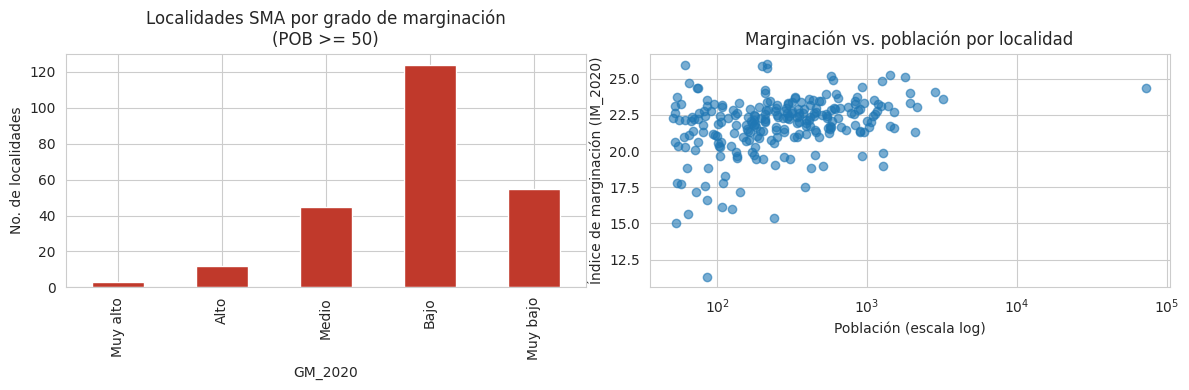

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sma_iml_validas.GM_2020.value_counts().reindex(
    ['Muy alto','Alto','Medio','Bajo','Muy bajo']).plot(kind='bar', ax=axes[0], color='#c0392b')
axes[0].set_title('Localidades SMA por grado de marginación\n(POB >= 50)')
axes[0].set_ylabel('No. de localidades')

axes[1].scatter(sma_iml_validas.POB_TOT, sma_iml_validas.IM_2020, alpha=0.6)
axes[1].set_xscale('log')
axes[1].set_xlabel('Población (escala log)')
axes[1].set_ylabel('Índice de marginación (IM_2020)')
axes[1].set_title('Marginación vs. población por localidad')
plt.tight_layout()
plt.savefig('../reports/figures/sma_marginacion_localidades.png', dpi=120)
plt.show()


## 3. Índice de marginación urbana por colonia (CONAPO, `imuc_2020`)

Esta base cubre las **colonias de la cabecera municipal** de SMA. A diferencia de `iml_2020` (escala ~0-30),
`IM_2020` en esta base usa **otra escala** (~135-156) — son índices con metodologías distintas y **no son
comparables directamente entre sí**. Esto se documenta para evitar mezclarlos sin normalizar.


In [9]:
df_imuc = pd.read_csv(RAW + 'imuc_2020.csv', encoding='utf-8')
sma_imuc = df_imuc[df_imuc.CVE_MUN == 11003].copy()
print('Colonias SMA (cabecera):', sma_imuc.shape)
sma_imuc[['CVE_COL','COLONIA','CLASIF','POB_TOT','IM_2020','GM_2020']].head()


Colonias SMA (cabecera): (121, 31)


,CVE_COL,COLONIA,CLASIF,POB_TOT,IM_2020,GM_2020
16848,11003_0001,Acuarela,Villa,25.691498,150.763911,Bajo
16849,11003_0002,Adolfo Lopez Mateos,Colonia,2792.449970,141.470095,Muy alto
16850,11003_0003,Allende,Colonia,1285.836163,148.305732,Medio
16851,11003_0004,Allende,Fraccionamiento,581.690587,151.350522,Bajo
16852,11003_0005,Arboledas,Fraccionamiento,462.361053,151.255156,Bajo


### 3.1 Nulos en `imuc_2020` (SMA)


In [10]:
null_pct_imuc = (sma_imuc.isnull().mean() * 100).sort_values(ascending=False)
print(null_pct_imuc[null_pct_imuc > 0])
print()
print(sma_imuc.CLASIF.value_counts())
print()
print('POB_TOT == 0 o NaN:', ((sma_imuc.POB_TOT.isnull()) | (sma_imuc.POB_TOT == 0)).sum())


NOM_SUN       100.00000
SUN_2018      100.00000
fn_COLONIA    100.00000
CVE_LOC         6.61157
NOM_LOC         6.61157
dtype: float64

CLASIF
Colonia                  50
Fraccionamiento          42
Residencial              11
Barrio                    7
Villa                     3
Zona militar              2
-                         2
Localidad                 2
Unidad habitacional       1
Conjunto habitacional     1
Name: count, dtype: int64

POB_TOT == 0 o NaN: 0


### 3.2 Decisiones de limpieza — `imuc_2020`

- `CLASIF == '-'` (sin clasificación, 2 registros "Sin Nombre") se recodifica como **"Sin clasificar"** en lugar
  de dejar el guion, por claridad en visualizaciones.
- `POB_TOT` viene como valor decimal (estimación censal con factores de expansión); se conserva tal cual — no es
  un error.
- No se detectaron nulos relevantes en `IM_2020`/`GM_2020` para colonias de SMA — todas las 121 colonias tienen
  índice calculado, por lo que **no se requiere imputación** en esta base.
- Para el análisis de prioridad urbana, se normaliza `IM_2020` de esta base a un **z-score interno** (entre las
  121 colonias de SMA) para poder construir un ranking, ya que la escala absoluta no es comparable con `iml_2020`.


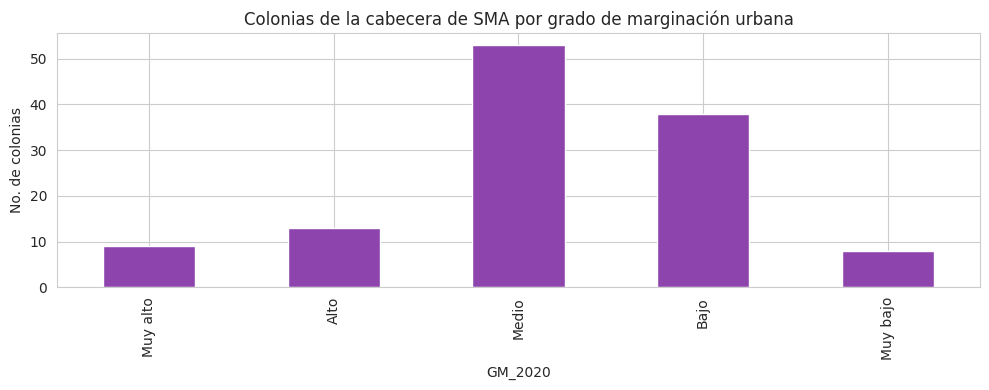

,COLONIA,CLASIF,POB_TOT,IM_2020,GM_2020
16872,El Milagro,Zona militar,24.440170,155.761451,Muy bajo
16878,El Secreto,Zona militar,30.313764,155.225894,Muy bajo
16906,La Parroquia,Fraccionamiento,146.857864,152.907232,Muy bajo
16907,La Parroquia Ii,Fraccionamiento,123.817093,152.907232,Muy bajo
16939,San Angel,Colonia,117.003441,152.907232,Muy bajo
16867,El Atrio,Colonia,120.811127,152.907231,Muy bajo
16902,La Escondida,Residencial,29.648207,152.907231,Muy bajo
16866,Deportiva,Colonia,427.619144,152.906986,Muy bajo
16896,Jardines 11,Fraccionamiento,57.708004,152.377049,Bajo
16916,Los Adobes,Fraccionamiento,43.399193,152.265984,Bajo


In [11]:
sma_imuc['CLASIF'] = sma_imuc['CLASIF'].replace('-', 'Sin clasificar')
sma_imuc['marginacion_z'] = (sma_imuc.IM_2020 - sma_imuc.IM_2020.mean()) / sma_imuc.IM_2020.std()

fig, ax = plt.subplots(figsize=(10, 4))
sma_imuc.GM_2020.value_counts().reindex(['Muy alto','Alto','Medio','Bajo','Muy bajo']).plot(kind='bar', ax=ax, color='#8e44ad')
ax.set_title('Colonias de la cabecera de SMA por grado de marginación urbana')
ax.set_ylabel('No. de colonias')
plt.tight_layout()
plt.savefig('../reports/figures/sma_marginacion_colonias.png', dpi=120)
plt.show()

# Top 10 colonias con mayor marginación (mayor IM_2020 en esta escala = mayor marginación)
top_colonias_marg = sma_imuc.sort_values('IM_2020', ascending=False)[
    ['COLONIA','CLASIF','POB_TOT','IM_2020','GM_2020']].head(10)
top_colonias_marg


## 4. Crosswalk: unidades de salud (CLUES) ↔ localidades (`iml_2020`)

De las 22 unidades de salud de SMA, 21 son **UMAPS / ESI / Caravanas** que atienden una localidad rural específica
(su nombre lo indica, p. ej. `ALCOCER-UMAPS` → localidad *Alcocer*), y 1 es el **CAISES** que atiende la cabecera
municipal (urbana).

Construimos el crosswalk manualmente revisando los 22 nombres contra las 331 localidades de `iml_2020`.


In [12]:
# Mapeo CLUES -> nombre de localidad en iml_2020
crosswalk = {
    'AGUSTIN GONZALEZ-UMAPS': 'Agustín González',
    'ALCOCER-UMAPS': 'Alcocer',
    'CORRAL DE PIEDRAS DE ARRIBA-UMAPS': 'Corral de Piedras de Arriba',
    'CORRALEJO DE ARRIBA (CORRALEJO)-UMAPS': 'Corralejo de Arriba',
    'E.S.I. 26 LA CAMPANA': 'La Campana',
    'ESI 17 DON FRANCISCO': 'Don Francisco',
    'ESI 42 LA PUERTA': None,  # 'La Puerta' no aparece con POB suficiente en iml_2020 (CVE_LOC 110030221, pob=180)
    'FAJARDO DE BOCAS-UMAPS': 'Fajardo de Bocas',
    'GALVANES-UMAPS': 'Los Galvanes',
    'JALPA-UMAPS': 'Jalpa',
    'LA CIENEGUITA-UMAPS': 'La Cieneguita',
    'LA CRUZ DEL PALMAR-UMAPS': 'La Cruz del Palmar',
    'LA PALMILLA-UMAPS': 'La Palmilla',
    'LA TALEGA-UMAPS': 'La Talega',
    'LOS RODRIGUEZ-UMAPS': 'Los Rodríguez',
    'PUERTO DE NIETO-UMAPS': 'Puerto de Nieto',
    'SAN JOSE DE ALLENDE-UMAPS': 'San José de Allende',
    'SAN MIGUEL DE ALLENDE-CAISES': 'San Miguel de Allende',  # cabecera -> se trata aparte (colonias)
    'SAN MIGUELITO-UMAPS': 'San Miguelito',
    'SANTUARIO DE ATOTONILCO (ATOTONILCO)-UMAPS': 'Santuario de Atotonilco',
    'CARAVANA TIPO 0 LA HUERTA': 'La Huerta',
    'CARAVANA TIPO II CIENEGA DE JUANA RUIZ': 'Ciénega de Juana Ruiz',
}

# corregir 'La Puerta' con búsqueda directa
match = sma_iml[sma_iml.NOM_LOC.str.contains('La Puerta', case=False, na=False)]
print(match[['NOM_LOC','POB_TOT','IM_2020']])
if not match.empty:
    crosswalk['ESI 42 LA PUERTA'] = match.iloc[0].NOM_LOC

sin_match = {k: v for k, v in crosswalk.items() if v is None}
print('Sin match:', sin_match)


         NOM_LOC  POB_TOT    IM_2020
26413  La Puerta      180  21.860343
Sin match: {}


### 4.1 Unión: carga de enfermedad + marginación a nivel localidad

Unimos `resumen_sis` (registros en control por CLUES, dic. 2023) con `sma_iml` (marginación + población 2020) a
través del crosswalk, y calculamos **tasas por cada 100 habitantes** para poder comparar localidades de
distintos tamaños.

Nota metodológica: los registros en control son de **2023** y la población de referencia es de **2020**
(censo). Puede haber crecimiento poblacional entre ambos años, por lo que las tasas son una **aproximación**, no
un valor exacto — se documenta para el reporte.


In [13]:
resumen_sis['localidad_iml'] = resumen_sis.NOMBRE_CLUES.map(crosswalk)

panel_loc = resumen_sis.merge(
    sma_iml[['NOM_LOC','POB_TOT','IM_2020','GM_2020','sin_indice_marginacion']],
    left_on='localidad_iml', right_on='NOM_LOC', how='left')

control_cols = ['control_diabetes','control_hipertension','control_obesidad',
                'control_dislipidemia','control_sx_metabolico']
panel_loc['control_total'] = panel_loc[control_cols].sum(axis=1)
panel_loc['tasa_control_x100hab'] = (panel_loc.control_total / panel_loc.POB_TOT * 100).round(2)

panel_loc_rural = panel_loc[panel_loc.NOMBRE_CLUES != 'SAN MIGUEL DE ALLENDE-CAISES'].copy()
panel_loc_rural[['NOMBRE_CLUES','localidad_iml','POB_TOT','control_total','tasa_control_x100hab','IM_2020','GM_2020']]


,NOMBRE_CLUES,localidad_iml,POB_TOT,control_total,tasa_control_x100hab,IM_2020,GM_2020
1,AGUSTIN GONZALEZ-UMAPS,Agustín González,670,403.0,60.15,21.664733,Bajo
2,ALCOCER-UMAPS,Alcocer,1094,448.0,40.95,22.428498,Bajo
3,SANTUARIO DE ATOTONILCO (ATOTONILCO)-UMAPS,Santuario de Atotonilco,637,292.0,45.84,23.701712,Muy bajo
4,E.S.I. 26 LA CAMPANA,La Campana,959,145.0,15.12,21.334361,Bajo
5,LA CIENEGUITA-UMAPS,La Cieneguita,1387,198.0,14.28,23.147112,Muy bajo
6,ESI 42 LA PUERTA,La Puerta,180,289.0,160.56,21.860343,Bajo
7,CORRAL DE PIEDRAS DE ARRIBA-UMAPS,Corral de Piedras de Arriba,2159,622.0,28.81,23.023294,Bajo
8,CORRALEJO DE ARRIBA (CORRALEJO)-UMAPS,Corralejo de Arriba,743,361.0,48.59,23.021195,Bajo
9,LA CRUZ DEL PALMAR-UMAPS,La Cruz del Palmar,1248,283.0,22.68,23.089420,Muy bajo
10,FAJARDO DE BOCAS-UMAPS,Fajardo de Bocas,340,304.0,89.41,22.383013,Bajo


## 5. Índice de prioridad sub-municipal (zonas rurales)

Para identificar localidades rurales prioritarias para programas de activación física, construimos un índice
compuesto (escala 0-100) con dos componentes, ponderados por igual dado que ambos representan dimensiones de
riesgo independientes y no contamos con datos de capacidad instalada deportiva a este nivel (a diferencia del
análisis municipal del notebook 05):

- **50% carga de enfermedad** — `tasa_control_x100hab` normalizada (0-100)
- **50% marginación** — `IM_2020` normalizado de forma inversa, ya que valores más negativos de `IM_2020`
  (escala CONAPO 2020) indican **mayor** marginación.

Localidades sin marginación calculada o con población < 50 (ver sección 2.2) se excluyen del ranking.


In [14]:
def normaliza_0_100(s):
    return (s - s.min()) / (s.max() - s.min()) * 100

base_prio = panel_loc_rural[~panel_loc_rural.IM_2020.isnull() & (panel_loc_rural.POB_TOT >= 50)].copy()

base_prio['score_enfermedad'] = normaliza_0_100(base_prio.tasa_control_x100hab)
# IM_2020 mas alto = menos marginado (CONAPO 2020+) -> invertimos
base_prio['score_marginacion'] = normaliza_0_100(-base_prio.IM_2020)

base_prio['prioridad_activacion'] = (0.5 * base_prio.score_enfermedad
                                      + 0.5 * base_prio.score_marginacion).round(1)

ranking = base_prio.sort_values('prioridad_activacion', ascending=False)[
    ['localidad_iml','POB_TOT','control_total','tasa_control_x100hab','GM_2020','prioridad_activacion']
].reset_index(drop=True)
ranking


,localidad_iml,POB_TOT,control_total,tasa_control_x100hab,GM_2020,prioridad_activacion
0,La Palmilla,383,203.0,53.00,Alto,65.4
1,La Puerta,180,289.0,160.56,Bajo,64.9
2,Don Francisco,1272,284.0,22.33,Medio,43.7
3,San José de Allende,925,197.0,21.30,Medio,38.2
4,Fajardo de Bocas,340,304.0,89.41,Bajo,37.8
5,Agustín González,670,403.0,60.15,Bajo,34.2
6,La Talega,417,340.0,81.53,Muy bajo,28.5
7,San Miguelito,331,298.0,90.03,Muy bajo,27.7
8,La Campana,959,145.0,15.12,Bajo,22.4
9,Alcocer,1094,448.0,40.95,Bajo,21.8


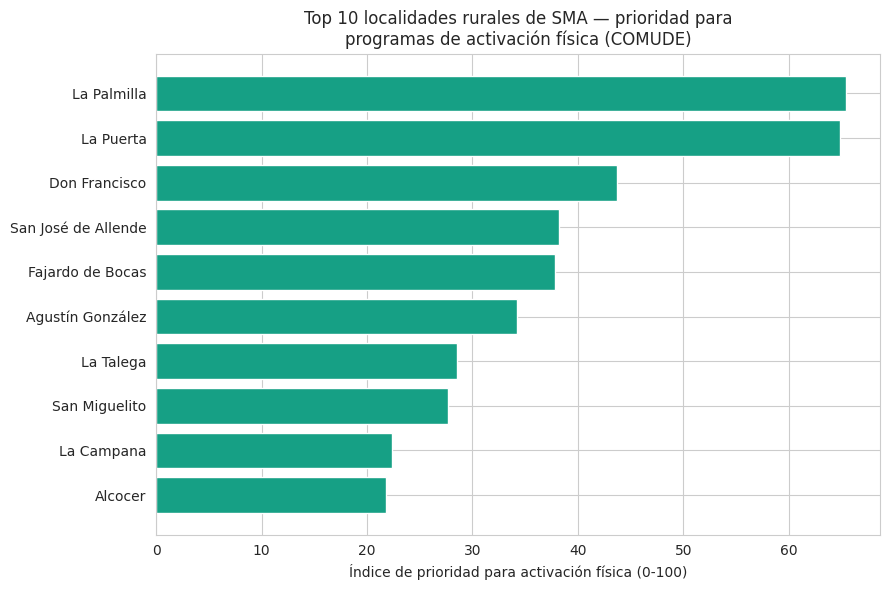

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
top = ranking.head(10)
ax.barh(top.localidad_iml[::-1], top.prioridad_activacion[::-1], color='#16a085')
ax.set_xlabel('Índice de prioridad para activación física (0-100)')
ax.set_title('Top 10 localidades rurales de SMA — prioridad para\nprogramas de activación física (COMUDE)')
plt.tight_layout()
plt.savefig('../reports/figures/sma_prioridad_localidades.png', dpi=120)
plt.show()


## 6. Zona urbana (cabecera): colonias prioritarias

Para la cabecera municipal —atendida por una sola unidad de salud (CAISES), por lo que no es posible desagregar
la carga de enfermedad por colonia— usamos `imuc_2020` para identificar las colonias con **mayor marginación
urbana relativa**, que son candidatas naturales para programas de activación física focalizados (espacios
públicos, canchas, parques).


In [16]:
top_colonias = sma_imuc.sort_values('marginacion_z', ascending=False)[
    ['COLONIA','CLASIF','POB_TOT','IM_2020','GM_2020','marginacion_z']].head(10).reset_index(drop=True)
top_colonias


,COLONIA,CLASIF,POB_TOT,IM_2020,GM_2020,marginacion_z
0,El Milagro,Zona militar,24.440170,155.761451,Muy bajo,2.053222
1,El Secreto,Zona militar,30.313764,155.225894,Muy bajo,1.897127
2,La Parroquia,Fraccionamiento,146.857864,152.907232,Muy bajo,1.221326
3,La Parroquia Ii,Fraccionamiento,123.817093,152.907232,Muy bajo,1.221326
4,San Angel,Colonia,117.003441,152.907232,Muy bajo,1.221326
5,El Atrio,Colonia,120.811127,152.907231,Muy bajo,1.221326
6,La Escondida,Residencial,29.648207,152.907231,Muy bajo,1.221326
7,Deportiva,Colonia,427.619144,152.906986,Muy bajo,1.221254
8,Jardines 11,Fraccionamiento,57.708004,152.377049,Bajo,1.066798
9,Los Adobes,Fraccionamiento,43.399193,152.265984,Bajo,1.034426


In [17]:
# contexto: registros en control en el CAISES (referencia para el reporte, no se desagrega por colonia)
caises = resumen_sis[resumen_sis.NOMBRE_CLUES == 'SAN MIGUEL DE ALLENDE-CAISES']
caises[['control_diabetes','control_hipertension','control_obesidad','control_dislipidemia','control_sx_metabolico']]


,control_diabetes,control_hipertension,control_obesidad,control_dislipidemia,control_sx_metabolico
0,1168.0,1454.0,788.0,1132.0,839.0


## 7. Exportar datasets procesados

Guardamos dos datasets para usarse en el dashboard y en la propuesta a COMUDE:

- `sma_localidades_panel.csv` — 1 fila por localidad rural con CLUES asociado, marginación, carga de enfermedad
  e índice de prioridad.
- `sma_colonias_panel.csv` — 1 fila por colonia de la cabecera con marginación urbana.


In [18]:
panel_loc_rural.merge(
    base_prio[['localidad_iml','score_enfermedad','score_marginacion','prioridad_activacion']],
    on='localidad_iml', how='left'
).to_csv(PROC + 'sma_localidades_panel.csv', index=False)

sma_imuc.to_csv(PROC + 'sma_colonias_panel.csv', index=False)

print('Guardado: sma_localidades_panel.csv', panel_loc_rural.shape)
print('Guardado: sma_colonias_panel.csv', sma_imuc.shape)


Guardado: sma_localidades_panel.csv (21, 15)
Guardado: sma_colonias_panel.csv (121, 32)


## 8. Resumen ejecutivo (para propuesta COMUDE)

**Hallazgos preliminares:**

- San Miguel de Allende tiene **22 unidades de salud**, 21 rurales/UMAPS + 1 CAISES en la cabecera.
- Se identificaron las localidades rurales con mayor combinación de **carga de enfermedad crónica** (tasa de
  adultos en control por diabetes/HTA/obesidad/dislipidemia por cada 100 habitantes) y **marginación** —
  candidatas prioritarias para llevar programas de activación física de COMUDE.
- En la cabecera municipal, las colonias con **mayor marginación urbana relativa** (top 10, sección 6) son
  candidatas para intervenciones focalizadas (parques, canchas, rutas de actividad física), complementando los
  hallazgos rurales.
- **Limitaciones a comunicar**: (1) las tasas de control combinan datos de 2023 (SIS) con población de 2020
  (CONAPO) — aproximación razonable pero no exacta; (2) la cabecera no se puede desagregar por colonia en cuanto
  a enfermedad, solo en marginación; (3) ~0 localidades muy pequeñas (POB < 50) se excluyeron del ranking
  por falta de índice de marginación o tamaño insuficiente para justificar un programa dedicado.

Este análisis complementa — sin sustituir — el índice de priorización municipal del notebook 05: mientras aquél
ranquea los 20 municipios de Guanajuato entre sí, este notebook **abre el municipio de SMA** para encontrar dónde,
dentro de él, haría más sentido empezar.
